### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
import time
import joblib

sns.set_theme(style="whitegrid")
SEED = 42

### Loading Data

In [2]:
white_wine_data = pd.read_csv(r"..\wine_data\winequality-white.csv", sep=";")
red_wine_data = pd.read_csv(r"..\wine_data\winequality-red.csv", sep=";")

white_wine_data.columns = white_wine_data.columns.str.strip().str.lower().str.replace(" ", "_")
red_wine_data.columns = red_wine_data.columns.str.strip().str.lower().str.replace(" ", "_")

white_wine_data['type'] = 1
red_wine_data['type'] = 0

wine_data_frame = pd.concat([white_wine_data, red_wine_data], ignore_index=True)

print(f"Shape: {wine_data_frame.shape}")
print(wine_data_frame.head(5).round(3).to_string())

Shape: (6497, 13)
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  free_sulfur_dioxide  total_sulfur_dioxide  density    ph  sulphates  alcohol  quality  type
0            7.0              0.27         0.36            20.7      0.045                 45.0                 170.0    1.001  3.00       0.45      8.8        6     1
1            6.3              0.30         0.34             1.6      0.049                 14.0                 132.0    0.994  3.30       0.49      9.5        6     1
2            8.1              0.28         0.40             6.9      0.050                 30.0                  97.0    0.995  3.26       0.44     10.1        6     1
3            7.2              0.23         0.32             8.5      0.058                 47.0                 186.0    0.996  3.19       0.40      9.9        6     1
4            7.2              0.23         0.32             8.5      0.058                 47.0                 186.0    0.996  3.19       0.4

In [3]:
def group_quality_scores(score):
    if score <= 4:
        return 0
    elif score <= 6:
        return 1
    elif score <= 9:
        return 2
    else:
        return None


wine_data_frame["quality_bin"] = wine_data_frame["quality"].apply(group_quality_scores)

print(wine_data_frame["quality_bin"].value_counts())
print("\n0=low, 1=medium, 2=high")

quality_bin
1    4974
2    1277
0     246
Name: count, dtype: int64

0=low, 1=medium, 2=high


### Prepare Features and Labels

In [4]:
X = wine_data_frame.drop(columns=["quality", "quality_bin", "type"]).values
y = wine_data_frame[["quality_bin", "type"]].values

# also keeping quality separately for stratified split
y_quality = wine_data_frame["quality_bin"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6497, 11)
y shape: (6497, 2)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y_quality)

y_train_q = y_train[:, 0]
y_train_t = y_train[:, 1]
y_test_q = y_test[:, 0]
y_test_t = y_test[:, 1]

print("train size:", len(X_train))
print("test size:", len(X_test))

train size: 5197
test size: 1300


In [6]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Scaling done")

Scaling done


In [7]:
y_comp = y_train_q * 10 + y_train_t

counts = np.bincount(y_comp)
k = max(1, min(5, counts.min() - 1))

print("smote k neighbors:", k)

smote = SMOTE(random_state=SEED, k_neighbors=k)
X_train_sm, y_comp_sm = smote.fit_resample(X_train_sc, y_comp)

# decode back
y_train_q_sm = y_comp_sm // 10
y_train_t_sm = y_comp_sm % 10
y_train_sm = np.column_stack([y_train_q_sm, y_train_t_sm])

print("before SMOTE:", len(X_train_sc))
print("after SMOTE:", len(X_train_sm))

smote k neighbors: 1
before SMOTE: 5197
after SMOTE: 17562


### Defining all Models to Compare

In [8]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=SEED),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=SEED),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
    "Naive Bayes": GaussianNB()
}

In [9]:
# helper function to collect metrics for both outputs

def evaluate(name, y_true, y_pred):
    out = {"model": name}

    for i, target in enumerate(["quality", "type"]):
        yt = y_true[:, i]
        yp = y_pred[:, i]

        out[f"{target}_acc"] = accuracy_score(yt, yp)
        out[f"{target}_f1"] = f1_score(yt, yp, average="weighted")
        out[f"{target}_precision"] = precision_score(yt, yp, average="weighted")
        out[f"{target}_recall"] = recall_score(yt, yp, average="weighted")

    return out

### Training all Models and Collecting results

In [10]:
results = []
trained = {}

for name, model in models.items():
    start = time.time()

    mo = MultiOutputClassifier(model)
    mo.fit(X_train_sm, y_train_sm)

    preds = mo.predict(X_test_sc)

    res = evaluate(name, y_test, preds)
    res["time_sec"] = round(time.time() - start, 2)

    results.append(res)
    trained[name] = mo

    print(name, "- time taken", res["time_sec"], "s")

results_df = pd.DataFrame(results).set_index("model")
results_df.round(3)

KNN - time taken 0.2 s
Random Forest - time taken 16.54 s
SVM - time taken 40.27 s
XGBoost - time taken 0.8 s
Logistic Regression - time taken 0.26 s
Naive Bayes - time taken 0.05 s


,quality_acc,quality_f1,quality_precision,quality_recall,type_acc,type_f1,type_precision,type_recall,time_sec
model,,,,,,,,,
KNN,0.682,0.711,0.784,0.682,0.994,0.994,0.994,0.994,0.20
Random Forest,0.841,0.834,0.830,0.841,0.995,0.995,0.995,0.995,16.54
SVM,0.629,0.669,0.788,0.629,0.995,0.995,0.995,0.995,40.27
XGBoost,0.824,0.820,0.818,0.824,0.996,0.996,0.996,0.996,0.80
Logistic Regression,0.513,0.561,0.748,0.513,0.993,0.993,0.993,0.993,0.26
Naive Bayes,0.535,0.574,0.746,0.535,0.978,0.978,0.978,0.978,0.05


In [ ]:
# doing it manually because cross_validate doesn't handle multioutput well

from sklearn.model_selection import KFold

print("running cross validation, this might take a while...\n")

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for name, model in models.items():
    fold_scores = []

    for train_idx, val_idx in kf.split(X_train_sc):
        X_tr, X_val   = X_train_sc[train_idx], X_train_sc[val_idx]
        y_tr_comp     = y_train[:, 0][train_idx] * 10 + y_train[:, 1][train_idx]
        y_val_q       = y_train[:, 0][val_idx]

        X_tr_sm, y_tr_comp_sm = SMOTE(random_state=SEED).fit_resample(X_tr, y_tr_comp)
        y_tr_sm = np.column_stack([y_tr_comp_sm // 10, y_tr_comp_sm % 10])

        mo = MultiOutputClassifier(model)
        mo.fit(X_tr_sm, y_tr_sm)
        preds = mo.predict(X_val)

        fold_scores.append(accuracy_score(y_val_q, preds[:, 0]))

    fold_scores = np.array(fold_scores)

    cv_results.append({
        "model": name,
        "cv_mean": fold_scores.mean(),
        "cv_std": fold_scores.std()
    })

    print(f"{name}: {fold_scores.mean():.3f} ± {fold_scores.std():.3f}")

cv_df = pd.DataFrame(cv_results).set_index("model").sort_values("cv_mean", ascending=False)
cv_df.round(3)

running cross validation, this might take a while...

KNN: 0.683 ± 0.011
Random Forest: 0.837 ± 0.008
SVM: 0.649 ± 0.011
XGBoost: 0.819 ± 0.012
Logistic Regression: 0.540 ± 0.011
Naive Bayes: 0.529 ± 0.016


,cv_mean,cv_std
model,,
Random Forest,0.837,0.008
XGBoost,0.819,0.012
KNN,0.683,0.011
SVM,0.649,0.011
Logistic Regression,0.540,0.011
Naive Bayes,0.529,0.016


### Plotting Quality, Accuracy and F1-score for all Models

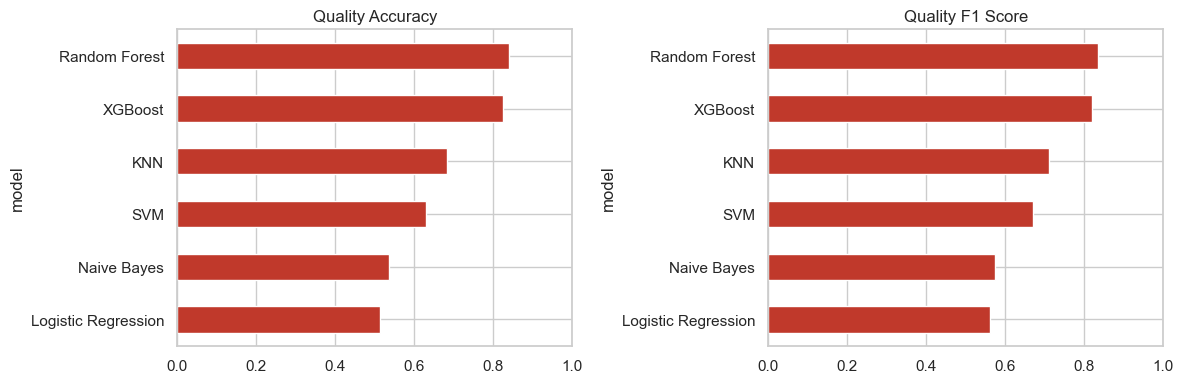

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df["quality_acc"].sort_values().plot(
    kind="barh", ax=axes[0], color="#C0392B"
)
axes[0].set_title("Quality Accuracy")
axes[0].set_xlim(0, 1)

results_df["quality_f1"].sort_values().plot(
    kind="barh", ax=axes[1], color="#C0392B"
)
axes[1].set_title("Quality F1 Score")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("../figures/ml_development_figures/fig1_model_performances_for_quality.png", bbox_inches='tight')
plt.show()

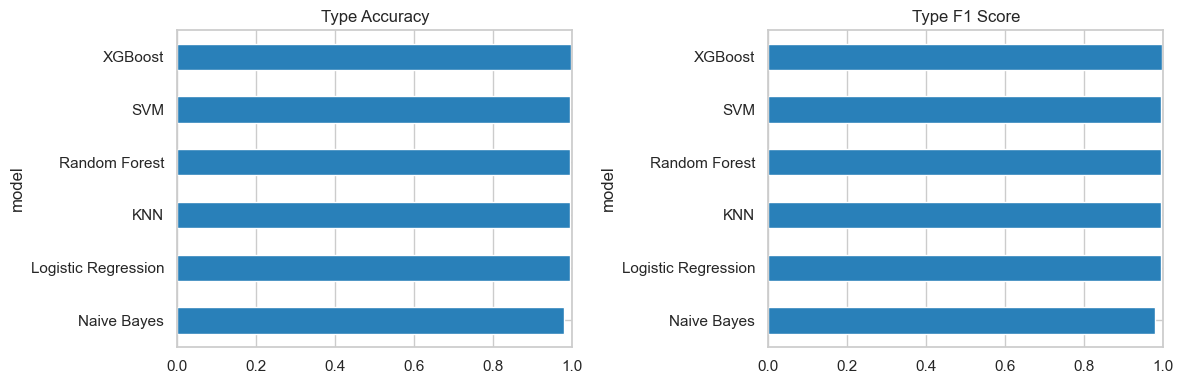

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results_df["type_acc"].sort_values().plot(
    kind="barh", ax=axes[0], color="#2980B9"
)
axes[0].set_title("Type Accuracy")
axes[0].set_xlim(0, 1)

results_df["type_f1"].sort_values().plot(
    kind="barh", ax=axes[1], color="#2980B9"
)
axes[1].set_title("Type F1 Score")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("../figures/ml_development_figures/fig2_model_performances_for_type.png", bbox_inches='tight')
plt.show()

### Picking Best Model based on Quality accuracy, because all models permorfed almost perfectly with type classification

In [14]:
best_name = results_df["quality_acc"].idxmax()
print("best model:", best_name)
print("quality accuracy:", round(results_df.loc[best_name, "quality_acc"], 3))
print("type accuracy:", round(results_df.loc[best_name, "type_acc"], 3))

best model: Random Forest
quality accuracy: 0.841
type accuracy: 0.995


### Hyperparameter Tuning on the best model using Gridsearch

In [15]:
param_grid = {
    "estimator__n_estimators": [100, 200, 300],
    "estimator__max_depth": [None, 10, 20],
    "estimator__min_samples_split": [2, 5]
}

grid = GridSearchCV(
    MultiOutputClassifier(RandomForestClassifier(random_state=SEED)),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_sm, y_train_sm)

print("\nbest params:", grid.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits

best params: {'estimator__max_depth': None, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 100}


# Evaluating Tuned Model on test set

In [16]:
tuned_preds = grid.best_estimator_.predict(X_test_sc)

tuned_res = evaluate("Random Forest (tuned)", y_test, tuned_preds)

print("quality accuracy:", round(tuned_res["quality_acc"], 3))
print("type accuracy:", round(tuned_res["type_acc"], 3))
print("quality f1:", round(tuned_res["quality_f1"], 3))

quality accuracy: 0.835
type accuracy: 0.995
quality f1: 0.827


# Confusion Matrix for Quality Prediction

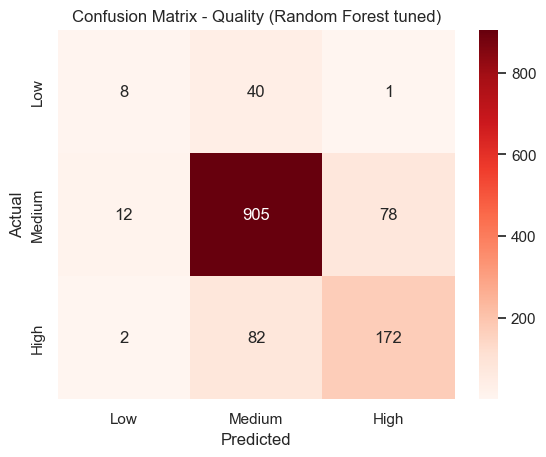

In [17]:
cm = confusion_matrix(y_test_q, tuned_preds[:, 0])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.title("Confusion Matrix - Quality (Random Forest tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("../figures/ml_development_figures/fig3_confusion_matrix_random_forest.png", bbox_inches='tight')
plt.show()

## Classification reports

### Quality

In [18]:
print(classification_report(
    y_test_q,
    tuned_preds[:, 0],
    target_names=["Low", "Medium", "High"]
))


              precision    recall  f1-score   support

         Low       0.36      0.16      0.23        49
      Medium       0.88      0.91      0.90       995
        High       0.69      0.67      0.68       256

    accuracy                           0.83      1300
   macro avg       0.64      0.58      0.60      1300
weighted avg       0.82      0.83      0.83      1300



### Type

In [19]:
print(classification_report(
    y_test_t,
    tuned_preds[:, 1],
    target_names=["Red", "White"]
))

              precision    recall  f1-score   support

         Red       0.99      0.99      0.99       320
       White       1.00      1.00      1.00       980

    accuracy                           1.00      1300
   macro avg       0.99      0.99      0.99      1300
weighted avg       1.00      1.00      1.00      1300



### Feature Importance 

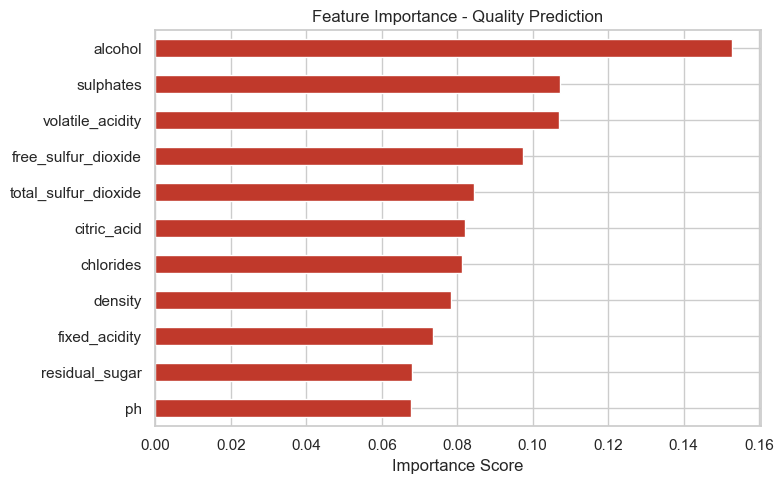


top 3 features:
alcohol             0.152726
sulphates           0.107237
volatile_acidity    0.107046
dtype: float64


In [20]:
feature_names = wine_data_frame.drop(columns=["quality", "quality_bin", "type"]).columns

rf_quality_estimator = grid.best_estimator_.estimators_[0]

importances = pd.Series(
    rf_quality_estimator.feature_importances_,
    index=feature_names
).sort_values()

importances.plot(kind="barh", figsize=(8, 5), color="#C0392B")
plt.title("Feature Importance - Quality Prediction")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../figures/ml_development_figures/fig4_feature_importance_random_forest.png", bbox_inches='tight')
plt.show()

print("\ntop 3 features:")
print(importances.sort_values(ascending=False).head(3))

### Saving the model and Scaler for the app

In [21]:
joblib.dump(grid.best_estimator_, "../model_folder/best_wine_model.pkl")
joblib.dump(scaler, "../model_folder/wine_scaler.pkl")

print("Model and Scaler are saved")

Model and Scaler are saved
